In [9]:
import numpy as np
import rasterio
import xml.etree.ElementTree as ET
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import scipy.ndimage

In [10]:
SLC_PATH = "Biomass_data/Test_Scene/20260204.hh.slc"
SLC_PAR_PATH = "Biomass_data/Test_Scene/20260204.hh.slc.par"
ANNOT_XML = "Biomass_data/BIO_S2_SCS__1S_20260204T154918_20260204T154941_T_G01_M01_CDR_T010_F183_01_DMKHUB/annotation/bio_s2_scs__1s_20260204t154918_20260204t154941_t_g01_m01_cdr_t010_f183_annot.xml"

In [38]:
# Windowing for CDE DC estimation
WIN_AZ = 512
WIN_RG = 100
STRIDE_AZ = 256
STRIDE_RG = 100

In [39]:
SLC_PATH = "Biomass_data/desert_scene/BIO_dessert.hh.slc"
SLC_PAR_PATH = "Biomass_data/desert_scene/BIO_dessert.hh.slc.par"
ANNOT_XML = "Biomass_data/desert_scene/BIO_S2_SCS__1S_20260202T174434_20260202T174457_T_G01_M01_CDR_T026_F137_01_DMKLZR/annotation/bio_s2_scs__1s_20260202t174434_20260202t174457_t_g01_m01_cdr_t026_f137_annot.xml"

In [40]:
# =========================
# Helper Functions
# =========================

def iso_to_unix(iso_str: str) -> float:
    """
    Convert ISO8601 (no timezone) to unix seconds (assume UTC).
    Example: '2026-02-04T15:49:18.236719'
    """
    dt = datetime.fromisoformat(iso_str).replace(tzinfo=timezone.utc)
    return dt.timestamp()

def eval_poly_horner(coeffs: np.ndarray, t: float, t0: float) -> float:
    """
    Evaluate polynomial sum_{k=0}^{n-1} coeffs[k] * (t - t0)^k using Horner.
    coeffs are [c0, c1, c2, ...].
    """
    dt = t - t0
    y = 0.0
    for c in reversed(coeffs):
        y = y * dt + c
    return float(y)

In [41]:
# =========================
# 1) Read SLC
# =========================

def parse_slc_par(par_file):
    params = {}
    with open(par_file, 'r') as f:
        for line in f:
            if ':' in line:
                key, _, val = line.partition(':')
                params[key.strip()] = val.strip().split()
    return params

par = parse_slc_par(SLC_PAR_PATH)

range_samples = int(par['range_samples'][0])
azimuth_lines = int(par['azimuth_lines'][0])

def read_slc(slc_file, range_samples, azimuth_lines):
    dt = np.dtype('>f4')
    raw = np.fromfile(slc_file, dtype=dt)
    complex_data = raw[0::2] + 1j * raw[1::2]
    return complex_data.reshape(azimuth_lines, range_samples)

slc = read_slc(SLC_PATH, range_samples, azimuth_lines)

In [42]:
# =========================
# 2) Parse annotation: sampling + doppler polynomials
# =========================
root = ET.parse(ANNOT_XML).getroot()

t_r0 = float(root.findtext(".//firstSampleSlantRangeTime"))
dt_r = float(root.findtext(".//rangeTimeInterval"))

t_a0_unix = iso_to_unix(root.findtext(".//firstLineAzimuthTime"))
dt_a = float(root.findtext(".//azimuthTimeInterval"))

F_az = 1.0 / dt_a

dc_estimates = []
for dc in root.findall(".//dopplerParameters//dcEstimateList//dcEstimate"):
    az_iso = dc.findtext("azimuthTime")
    t0 = dc.findtext("t0")
    poly = dc.findtext("geometryDCPolynomial")

    if az_iso is None or t0 is None or poly is None:
        continue

    az_unix = iso_to_unix(az_iso)
    t0 = float(t0)
    coeffs = np.array([float(x) for x in poly.split()], dtype=np.float64)

    dc_estimates.append((az_unix, t0, coeffs))

dc_times = np.array([e[0] for e in dc_estimates], dtype=np.float64)

In [43]:
# =========================
# 3) Compute measured DC map + predicted DC map + DCA map
# =========================
n_az = (slc.shape[0] - WIN_AZ) // STRIDE_AZ + 1
n_rg = (slc.shape[1] - WIN_RG) // STRIDE_RG + 1

f_meas_map = np.full((n_az, n_rg), np.nan, dtype=np.float32)
f_pred_map = np.full((n_az, n_rg), np.nan, dtype=np.float32)
dca_map    = np.full((n_az, n_rg), np.nan, dtype=np.float32)

for i in range(n_az):
    a0 = i * STRIDE_AZ
    a_center = a0 + WIN_AZ // 2

    t_a = t_a0_unix + a_center * dt_a

    idx = int(np.argmin(np.abs(dc_times - t_a)))
    az_unix, t0_poly, coeffs_poly = dc_estimates[idx]

    for j in range(n_rg):
        r0 = j * STRIDE_RG
        r_center = r0 + WIN_RG // 2

        t_r = t_r0 + r_center * dt_r

        f_pred = eval_poly_horner(coeffs_poly, t_r, t0_poly)

        patch = slc[a0:a0+WIN_AZ, r0:r0+WIN_RG]
        C = patch[1:, :] * np.conj(patch[:-1, :])
        R1 = np.mean(C)
        phi = np.angle(R1)
        f_meas = -(F_az / (2.0*np.pi)) * phi

        f_meas_map[i, j] = f_meas
        f_pred_map[i, j] = f_pred
        dca_map[i, j]    = f_meas - f_pred



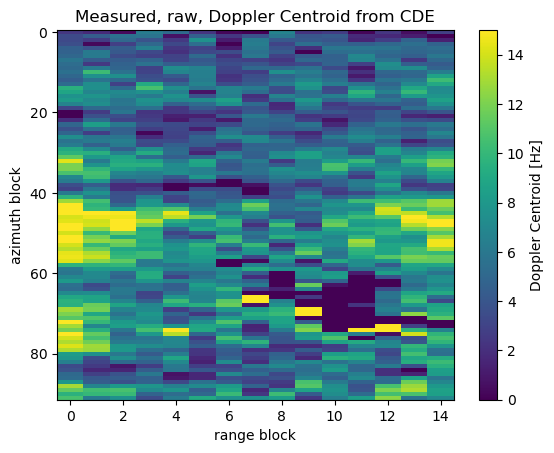

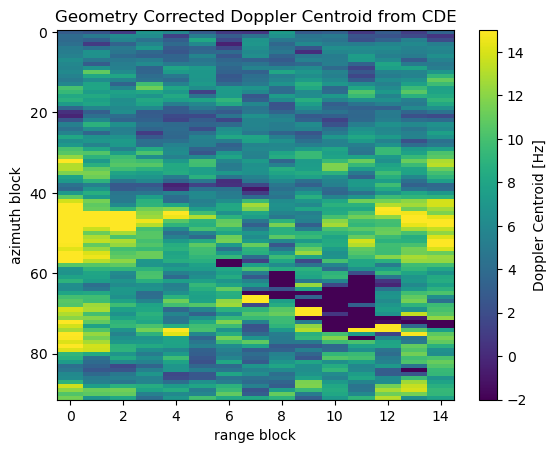

In [47]:
# =========================
# 4) Plot quicklooks
# =========================
plt.figure()
plt.title('Measured, raw, Doppler Centroid from CDE')
plt.imshow(f_meas_map, aspect="auto", vmin=0, vmax=15)
plt.ylabel('azimuth block')
plt.xlabel('range block')
plt.colorbar(label='Doppler Centroid [Hz]')

plt.figure()
plt.title("Geometry Corrected Doppler Centroid from CDE")
plt.imshow(dca_map, aspect="auto", vmin=-2, vmax=15)
plt.ylabel('azimuth block')
plt.xlabel('range block')
plt.colorbar(label='Doppler Centroid [Hz]')

plt.show()